<a href="https://colab.research.google.com/github/Maryvictor/laranja_artigo_medium/blob/main/laranja_codigo_regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('caderno.csv')

df

,numero,manchas,moleza,cor,podre
0,1,0,7,clara,0
1,2,6,9,media,1
2,3,1,3,escura,0
3,4,7,6,clara,1
4,5,6,6,escura,0
5,6,4,5,media,0
6,7,1,0,clara,0
7,8,1,9,media,0
8,9,8,4,escura,1
9,10,1,6,escura,0


In [3]:
#linhas e colunas
df.shape

(30, 5)

In [4]:
#informações do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   numero   30 non-null     int64 
 1   manchas  30 non-null     int64 
 2   moleza   30 non-null     int64 
 3   cor      30 non-null     object
 4   podre    30 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.3+ KB


In [5]:
#quantas de cada
df.groupby('podre').manchas.count()

,manchas
podre,
0,24
1,6


In [6]:
df = pd.get_dummies(data=df, columns=['cor'], dtype=int)

In [7]:
df.head()

,numero,manchas,moleza,podre,cor_clara,cor_escura,cor_media
0,1,0,7,0,1,0,0
1,2,6,9,1,0,0,1
2,3,1,3,0,0,1,0
3,4,7,6,1,1,0,0
4,5,6,6,0,0,1,0


In [8]:
df = df.drop(['numero'], axis=1)

In [9]:
df.head()

,manchas,moleza,podre,cor_clara,cor_escura,cor_media
0,0,7,0,1,0,0
1,6,9,1,0,0,1
2,1,3,0,0,1,0
3,7,6,1,1,0,0
4,6,6,0,0,1,0


In [10]:
x = df.drop('podre', axis=1)   # tudo MENOS a resposta
y = df['podre']                 # SÓ a resposta

In [11]:
x.head()

,manchas,moleza,cor_clara,cor_escura,cor_media
0,0,7,1,0,0
1,6,9,0,0,1
2,1,3,0,1,0
3,7,6,1,0,0
4,6,6,0,1,0


In [12]:
y.head()

,podre
0,0
1,1
2,0
3,1
4,0


In [13]:
from sklearn.model_selection import train_test_split

SEED = 42

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=SEED, stratify=y)

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(x_train, y_train)
pd.Series(lr.coef_[0], index=x.columns)

,0
manchas,1.105236
moleza,0.614940
cor_clara,-0.007026
cor_escura,-0.056506
cor_media,0.063117


In [15]:
y_pred = lr.predict(x_test)

In [16]:
print("Estava podre?  ", y_test.tolist())
print("O que ele disse:", y_pred.tolist())

Estava podre?   [1, 0, 0, 0, 0, 1, 0, 0]
O que ele disse: [1, 0, 0, 0, 0, 0, 0, 0]


In [17]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[6, 0],
       [1, 1]])

In [18]:
from sklearn import metrics

print("Acurácia:", metrics.accuracy_score(y_test, y_pred))
print("Recall:  ", metrics.recall_score(y_test, y_pred))
print("Precisão:", metrics.precision_score(y_test, y_pred))
print("F1:      ", metrics.f1_score(y_test, y_pred))

Acurácia: 0.875
Recall:   0.5
Precisão: 1.0
F1:       0.6666666666666666


In [19]:
y_proba = lr.predict_proba(x_test)[:, 1]

In [20]:
notas = pd.DataFrame({'era_podre': y_test, 'nota': y_proba.round(3)})
notas.sort_values('nota', ascending=False)

,era_podre,nota
3,1,0.652
10,1,0.276
29,0,0.025
25,0,0.016
14,0,0.002
9,0,0.002
19,0,0.000
11,0,0.000


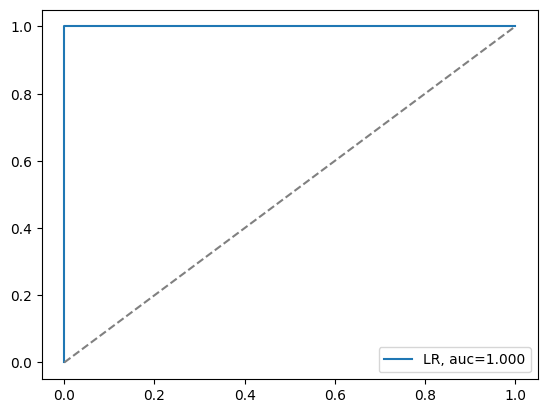

In [21]:
import matplotlib.pyplot as plt

fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)
auc = metrics.roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f"LR, auc={auc:.3f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.legend(loc=4)

In [22]:
for corte in [0.7, 0.5, 0.3, 0.2]:
    y_pred_novo = (y_proba >= corte).astype(int)
    print(corte, 'recall:', metrics.recall_score(y_test, y_pred_novo))

0.7 recall: 0.0
0.5 recall: 0.5
0.3 recall: 0.5
0.2 recall: 1.0
